In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

kaggle_config = {"username": "YOUR_KAGGLE_USERNAME", "key": "YOUR_KAGGLE_KEY"}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -o -q lgg-mri-segmentation.zip -d /content/segmentation
print(" Done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
lgg-mri-segmentation.zip: Skipping, found more recently modified local copy (use --force to force download)
--
 Done!


In [ ]:
import os, cv2, numpy as np
from sklearn.model_selection import train_test_split

SEG_PATH = '/content/segmentation/kaggle_3m'
IMG_SIZE  = 128

images, masks = [], []
patient_folders = sorted([f for f in os.listdir(SEG_PATH)
                           if os.path.isdir(os.path.join(SEG_PATH, f))])
print(f"Found {len(patient_folders)} folders")

skipped = 0
for folder in patient_folders:
    fp = os.path.join(SEG_PATH, folder)
    for img_file in [f for f in os.listdir(fp)
                     if f.endswith('.tif') and '_mask' not in f]:
        mask_file = img_file.replace('.tif', '_mask.tif')
        img_path  = os.path.join(fp, img_file)
        mask_path = os.path.join(fp, mask_file)
        if not os.path.exists(mask_path): continue

        # Load mask first — skip empty masks (no tumor)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
        if mask.max() == 0:
            skipped += 1
            continue

        img = cv2.imread(img_path)
        if img is None: continue
        img = cv2.cvtColor(cv2.resize(img, (IMG_SIZE, IMG_SIZE)),
                           cv2.COLOR_BGR2RGB) / 255.0
        mask = (cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) > 127).astype(np.float32)

        images.append(img)
        masks.append(np.expand_dims(mask, -1))

X_seg = np.array(images, dtype=np.float32)
y_seg = np.array(masks,  dtype=np.float32)

print(f" Loaded: {X_seg.shape}")
print(f" Skipped (no tumor): {skipped}")
print(f" Tumor pixel %: {y_seg.mean()*100:.2f}%")

X_train_seg, X_val_seg, y_train_seg, y_val_seg = train_test_split(
    X_seg, y_seg, test_size=0.2, random_state=42)
print(f" Train: {X_train_seg.shape} | Val: {X_val_seg.shape}")

Found 110 folders
 Loaded: (1373, 128, 128, 3)
 Skipped (no tumor): 2556
 Tumor pixel %: 3.04%
 Train: (1098, 128, 128, 3) | Val: (275, 128, 128, 3)


In [ ]:
import os, cv2, numpy as np, tensorflow as tf
from sklearn.model_selection import train_test_split

SEG_PATH = '/content/segmentation/kaggle_3m'
IMG_SIZE  = 256

# ── Collect all file paths only (no loading yet) ───────────
img_paths, mask_paths = [], []
patient_folders = sorted([f for f in os.listdir(SEG_PATH)
                           if os.path.isdir(os.path.join(SEG_PATH, f))])
print(f"Found {len(patient_folders)} folders")

for folder in patient_folders:
    fp = os.path.join(SEG_PATH, folder)
    for img_file in [f for f in os.listdir(fp)
                     if f.endswith('.tif') and '_mask' not in f]:
        mask_file = img_file.replace('.tif', '_mask.tif')
        img_path  = os.path.join(fp, img_file)
        mask_path = os.path.join(fp, mask_file)
        if os.path.exists(mask_path):
            img_paths.append(img_path)
            mask_paths.append(mask_path)

img_paths  = np.array(img_paths)
mask_paths = np.array(mask_paths)
print(f" Total pairs found: {len(img_paths)}")

# ── Split paths (not images) ───────────────────────────────
from sklearn.model_selection import train_test_split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    img_paths, mask_paths, test_size=0.2, random_state=42)
print(f" Train: {len(train_imgs)} | Val: {len(val_imgs)}")

# ── tf.data pipeline — loads from disk on the fly ──────────
def load_image_mask(img_path, mask_path):
    # Load image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE])
    mask = tf.cast(mask > 127, tf.float32)
    return img, mask

def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.clip_by_value(tf.image.random_brightness(img, 0.1), 0, 1)
    return img, mask

BATCH_SIZE = 16

train_ds = (tf.data.Dataset.from_tensor_slices((train_imgs, train_masks))
            .shuffle(len(train_imgs))
            .map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
            .map(augment,         num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((val_imgs, val_masks))
          .map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))


print(f" Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

Found 110 folders
 Total pairs found: 3929
 Train: 3143 | Val: 786
 Train batches: 197 | Val batches: 50


In [ ]:
# ── CELL 2 (fixed): Use OpenCV loader inside tf.data ──────
import os, numpy as np, tensorflow as tf
from sklearn.model_selection import train_test_split

SEG_PATH = '/content/segmentation/kaggle_3m'
IMG_SIZE  = 256

# Collect paths
img_paths, mask_paths = [], []
patient_folders = sorted([f for f in os.listdir(SEG_PATH)
                           if os.path.isdir(os.path.join(SEG_PATH, f))])
for folder in patient_folders:
    fp = os.path.join(SEG_PATH, folder)
    for img_file in [f for f in os.listdir(fp)
                     if f.endswith('.tif') and '_mask' not in f]:
        mask_file = img_file.replace('.tif', '_mask.tif')
        img_path  = os.path.join(fp, img_file)
        mask_path = os.path.join(fp, mask_file)
        if os.path.exists(mask_path):
            img_paths.append(img_path)
            mask_paths.append(mask_path)

print(f" Total pairs: {len(img_paths)}")

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    img_paths, mask_paths, test_size=0.2, random_state=42)
print(f" Train: {len(train_imgs)} | Val: {len(val_imgs)}")

# ── OpenCV loader (handles .tif) ───────────────────────────
import cv2

def load_pair(img_path, mask_path):
    def _load(ip, mp):
        ip = ip.decode('utf-8')
        mp = mp.decode('utf-8')
        img = cv2.imread(ip)
        img = cv2.cvtColor(cv2.resize(img, (IMG_SIZE, IMG_SIZE)),
                           cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        mask = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, -1)
        return img, mask

    img, mask = tf.numpy_function(_load, [img_path, mask_path],
                                  [tf.float32, tf.float32])
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.clip_by_value(tf.image.random_brightness(img, 0.1), 0, 1)
    return img, mask

BATCH_SIZE = 16

train_ds = (tf.data.Dataset.from_tensor_slices((train_imgs, train_masks))
            .shuffle(len(train_imgs))
            .map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
            .map(augment,   num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((val_imgs, val_masks))
          .map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

print(" Pipeline ready!")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

 Total pairs: 3929
 Train: 3143 | Val: 786
 Pipeline ready!
Train batches: 197 | Val batches: 50


In [ ]:
# ── CELL 3: Build U-Net ────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, Model

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(f, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def encoder_block(x, f):
    s = conv_block(x, f)
    p = layers.MaxPooling2D(2)(s)
    return s, p

def decoder_block(x, s, f):
    x = layers.UpSampling2D(2)(x)
    x = layers.Concatenate()([x, s])
    x = conv_block(x, f)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inp = layers.Input(input_shape)
    s1, p1 = encoder_block(inp, 64)
    s2, p2 = encoder_block(p1,  128)
    s3, p3 = encoder_block(p2,  256)
    s4, p4 = encoder_block(p3,  512)
    b      = conv_block(p4, 1024)
    d1 = decoder_block(b,  s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    out = layers.Conv2D(1, 1, activation='sigmoid')(d4)
    return Model(inp, out, name='UNet')

tf.keras.backend.clear_session()
unet = build_unet()
print(f" U-Net built! Params: {unet.count_params():,}")

 U-Net built! Params: 31,396,609


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2*intersection+smooth)/(
        tf.reduce_sum(y_true_f)+tf.reduce_sum(y_pred_f)+smooth)

def bce_dice_loss(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = 1 - (2*intersection+1e-6)/(
        tf.reduce_sum(y_true_f)+tf.reduce_sum(y_pred_f)+1e-6)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice

unet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef, 'accuracy']
)
print(" Compiled!")

BATCH_SIZE = 32
train_ds = (tf.data.Dataset.from_tensor_slices((train_imgs, train_masks))
            .shuffle(len(train_imgs))
            .map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
            .map(augment,   num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((val_imgs, val_masks))
          .map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

SEG_SAVE = '/content/drive/MyDrive/BrainTumorProject/best_unet.keras'

callbacks = [
    ModelCheckpoint(SEG_SAVE, monitor='val_dice_coef',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_dice_coef', patience=10,
                  mode='max', verbose=1,          # ← fixed
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_dice_coef', factor=0.5,
                      patience=4, min_lr=1e-7, mode='max', verbose=1)
]

print("\n Training U-Net...")
history = unet.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

_, dc, _ = unet.evaluate(val_ds, verbose=0)
print(f"\n Val Dice Score: {dc:.4f}")
print(f" Saved: {SEG_SAVE}")

NameError: name 'unet' is not defined

In [ ]:
# ── CELL 5: Visualize Predictions ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, val_ds, num_samples=6):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*4))
    axes[0,0].set_title('MRI Image',      fontsize=14)
    axes[0,1].set_title('Ground Truth',   fontsize=14)
    axes[0,2].set_title('U-Net Prediction', fontsize=14)

    sample_count = 0
    for imgs, masks in val_ds:
        preds = model.predict(imgs, verbose=0)
        for i in range(len(imgs)):
            if sample_count >= num_samples: break
            img  = imgs[i].numpy()
            mask = masks[i].numpy()[:,:,0]
            pred = (preds[i][:,:,0] > 0.5).astype(np.float32)

            axes[sample_count,0].imshow(img)
            axes[sample_count,0].axis('off')

            axes[sample_count,1].imshow(mask, cmap='gray')
            axes[sample_count,1].axis('off')

            axes[sample_count,2].imshow(pred, cmap='gray')
            axes[sample_count,2].axis('off')

            sample_count += 1
        if sample_count >= num_samples: break

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/BrainTumorProject/unet_predictions.png')
    plt.show()
    print(" Saved to Drive!")

visualize_predictions(unet, val_ds)

In [ ]:
# Visualize ONLY tumor cases
import matplotlib.pyplot as plt
import numpy as np

def visualize_tumor_predictions(model, val_ds, num_samples=6):
    tumor_imgs, tumor_masks, tumor_preds = [], [], []

    for imgs, masks in val_ds:
        preds = model.predict(imgs, verbose=0)
        for i in range(len(imgs)):
            mask = masks[i].numpy()[:,:,0]
            if mask.max() > 0:  # only tumor cases
                tumor_imgs.append(imgs[i].numpy())
                tumor_masks.append(mask)
                tumor_preds.append(preds[i][:,:,0])
            if len(tumor_imgs) >= num_samples:
                break
        if len(tumor_imgs) >= num_samples:
            break

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))
    axes[0,0].set_title('MRI Image',       fontsize=13)
    axes[0,1].set_title('Ground Truth',    fontsize=13)
    axes[0,2].set_title('Prediction',      fontsize=13)
    axes[0,3].set_title('Overlay',         fontsize=13)

    for i in range(num_samples):
        img  = tumor_imgs[i]
        mask = tumor_masks[i]
        pred = (tumor_preds[i] > 0.5).astype(np.float32)

        # Overlay — green=truth, red=prediction
        overlay = img.copy()
        overlay[:,:,1] = np.where(mask > 0.5,   1.0, overlay[:,:,1])  # green truth
        overlay[:,:,0] = np.where(pred > 0.5,   1.0, overlay[:,:,0])  # red pred

        axes[i,0].imshow(img);     axes[i,0].axis('off')
        axes[i,1].imshow(mask, cmap='gray'); axes[i,1].axis('off')
        axes[i,2].imshow(pred, cmap='gray'); axes[i,2].axis('off')
        axes[i,3].imshow(overlay); axes[i,3].axis('off')

        # Dice per sample
        intersection = (mask * pred).sum()
        dice = (2*intersection+1e-6)/(mask.sum()+pred.sum()+1e-6)
        axes[i,3].set_title(f'Dice: {dice:.3f}', fontsize=11)

    plt.suptitle('U-Net Tumor Segmentation Results', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/BrainTumorProject/unet_tumor_predictions.png',
                bbox_inches='tight')
    plt.show()
    print(" Saved!")

visualize_tumor_predictions(unet, val_ds)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2*intersection+smooth)/(
        tf.reduce_sum(y_true_f)+tf.reduce_sum(y_pred_f)+smooth)

def bce_dice_loss(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = 1-(2*intersection+1e-6)/(
        tf.reduce_sum(y_true_f)+tf.reduce_sum(y_pred_f)+1e-6)
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice

unet = tf.keras.models.load_model(
    '/content/drive/MyDrive/BrainTumorProject/best_unet.keras',
    custom_objects={'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef}
)
print("✅ Model loaded!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded!


In [ ]:
import cv2, matplotlib.pyplot as plt

def predict_single(model, img_path, mask_path=None):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(cv2.resize(img, (256,256)), cv2.COLOR_BGR2RGB)
    img_norm = img.astype(np.float32) / 255.0
    pred = model.predict(np.expand_dims(img_norm, 0), verbose=0)[0,:,:,0]
    pred_binary = (pred > 0.5).astype(np.float32)

    cols = 3 if mask_path else 2
    fig, axes = plt.subplots(1, cols, figsize=(5*cols, 5))
    axes[0].imshow(img); axes[0].set_title('MRI'); axes[0].axis('off')

    if mask_path:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (cv2.resize(mask,(256,256))>127).astype(np.float32)
        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title('Ground Truth'); axes[1].axis('off')
        axes[2].imshow(pred_binary, cmap='gray')
        axes[2].set_title('Prediction'); axes[2].axis('off')
    else:
        axes[1].imshow(pred_binary, cmap='gray')
        axes[1].set_title('Prediction'); axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    tumor = " Tumor Detected!" if pred_binary.max() > 0 else " No Tumor"
    print(tumor)

# Test with one image from Drive
# Give any .tif image path here
predict_single(
    unet,
    '/content/drive/MyDrive/BrainTumorProject/test_sample.tif'  # ← change this
)

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [ ]:
import os

# Find a real image path from the dataset
SEG_PATH = '/content/segmentation/kaggle_3m'

# Check if dataset exists
if os.path.exists(SEG_PATH):
    for folder in os.listdir(SEG_PATH)[:1]:
        fp = os.path.join(SEG_PATH, folder)
        for f in os.listdir(fp):
            if f.endswith('.tif') and '_mask' not in f:
                img_path  = os.path.join(fp, f)
                mask_path = os.path.join(fp, f.replace('.tif', '_mask.tif'))
                print(f"Image: {img_path}")
                print(f"Mask:  {mask_path}")
                break
else:
    print("❌ Dataset not found — need to re-download")

Image: /content/segmentation/kaggle_3m/TCGA_CS_6186_20000601/TCGA_CS_6186_20000601_4.tif
Mask:  /content/segmentation/kaggle_3m/TCGA_CS_6186_20000601/TCGA_CS_6186_20000601_4_mask.tif


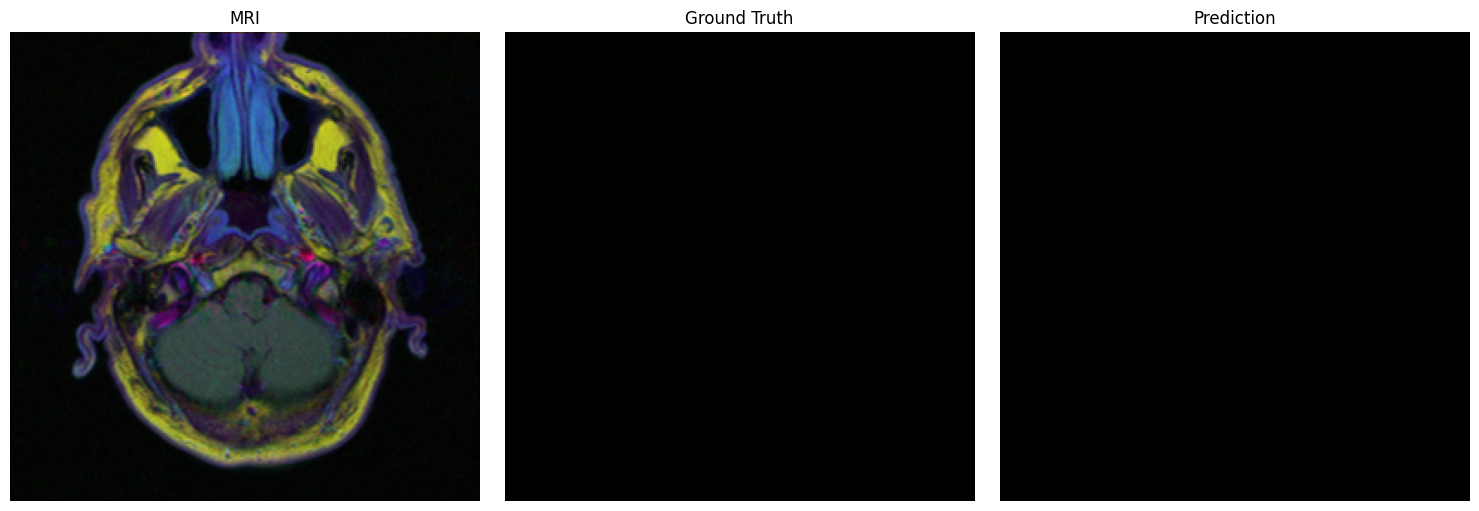

 No Tumor


In [ ]:
predict_single(unet, img_path, mask_path)